# Week 2 Internship Task
## Baseline Regression Modeling

### Steel Industry Energy Consumption Dataset

### Objective

This notebook uses the engineered dataset created during the exploratory
data analysis. Four regression models are trained and evaluated to establish
a baseline for predicting energy consumption.

### Models

1. Linear Regression
2. Ridge Regression
3. Decision Tree Regressor
4. Random Forest Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving steel_energy_engineered.csv to steel_energy_engineered.csv


In [3]:
df = pd.read_csv("steel_energy_engineered.csv")

print("Engineered dataset loaded successfully!")
print("Dataset shape:", df.shape)

Engineered dataset loaded successfully!
Dataset shape: (35040, 17)


In [4]:
df.head ()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_Extracted,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,Weekday,1.545117,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  Hour           

In [6]:
print("Columns:")
print(df.columns.tolist())

Columns:
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day_of_Week_Extracted', 'Month', 'Day_Type', 'Power_Factor_Ratio', 'High_Load']


In [7]:
# Separate target variable
y = df['Usage_kWh']

# Remove columns that should not be used for modeling
X = df.drop(columns=['Usage_kWh', 'date', 'High_Load'])

print("Target variable: Usage_kWh")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nRemaining features:")
print(X.columns.tolist())

Target variable: Usage_kWh
Features shape: (35040, 14)
Target shape: (35040,)

Remaining features:
['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'Day_of_Week_Extracted', 'Month', 'Day_Type', 'Power_Factor_Ratio']


In [8]:
# Identify categorical and numerical columns

categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['WeekStatus', 'Day_of_week', 'Load_Type', 'Day_Type']

Numerical features:
['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Hour', 'Day_of_Week_Extracted', 'Month', 'Power_Factor_Ratio']


In [10]:
# One-hot encoding for categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

print("One-hot encoding setup completed successfully!")

One-hot encoding setup completed successfully!


### Categorical Feature Encoding

One-hot encoding was selected for the categorical variables because the categories
such as Load Type, Day of week, WeekStatus, and Day_Type do not have a natural
numerical order.

Using one-hot encoding converts each category into a separate binary feature.
The `drop='first'` option is used to avoid unnecessary multicollinearity between
the generated dummy variables.

In [11]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (28032, 14)
Testing features: (7008, 14)
Training target: (28032,)
Testing target: (7008,)


In [12]:
# Define the four baseline regression models

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

print("Four regression models created successfully!")

Four regression models created successfully!


In [13]:
# Create a pipeline for each model

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Model pipelines created successfully!")

Model pipelines created successfully!


In [16]:
# Check missing values in the modeling data

print("Missing values in X:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values in X:
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
Hour                                    0
Day_of_Week_Extracted                   0
Month                                   0
Day_Type                                0
Power_Factor_Ratio                      1
dtype: int64

Total missing values: 1


In [17]:
from sklearn.impute import SimpleImputer

print("SimpleImputer imported successfully!")

SimpleImputer imported successfully!


In [18]:
# Preprocessing for categorical and numerical features

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', categorical_transformer, categorical_features),
        ('numerical', numerical_transformer, numerical_features)
    ]
)

print("Preprocessing pipeline updated successfully!")

Preprocessing pipeline updated successfully!


In [19]:
# Recreate model pipelines with the updated preprocessing

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("Model pipelines recreated successfully!")

Model pipelines recreated successfully!


In [20]:
# Train and evaluate all four models

results = []

for name, pipeline in pipelines.items():

    print(f"Training {name}...")

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results)

print("\nModel Evaluation Results:")
display(results_df)

Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...
Training Random Forest...

Model Evaluation Results:


,Model,MAE,RMSE,R2
0,Linear Regression,2.633882,4.146028,0.984878
1,Ridge Regression,4.360434,6.266551,0.965454
2,Decision Tree,0.533098,1.473699,0.998089
3,Random Forest,0.354125,1.043907,0.999041


In [21]:
# 5-Fold Cross-Validation

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, pipeline in pipelines.items():

    print(f"Running 5-fold CV for {name}...")

    # Negative RMSE because sklearn uses "higher is better"
    cv_scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=kf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    # Convert negative RMSE to positive RMSE
    rmse_scores = -cv_scores

    cv_results.append({
        'Model': name,
        'Mean CV RMSE': rmse_scores.mean(),
        'Std CV RMSE': rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print("\n5-Fold Cross-Validation Results:")
display(cv_results_df)

Running 5-fold CV for Linear Regression...
Running 5-fold CV for Ridge Regression...
Running 5-fold CV for Decision Tree...
Running 5-fold CV for Random Forest...

5-Fold Cross-Validation Results:


,Model,Mean CV RMSE,Std CV RMSE
0,Linear Regression,4.512535,0.407284
1,Ridge Regression,6.228499,0.092360
2,Decision Tree,1.478499,0.054585
3,Random Forest,1.025234,0.074478


In [22]:
# Combine test-set and cross-validation results

comparison_df = results_df[['Model', 'MAE', 'RMSE', 'R2']].merge(
    cv_results_df,
    on='Model'
)

print("Final Model Comparison:")
display(comparison_df)

Final Model Comparison:


,Model,MAE,RMSE,R2,Mean CV RMSE,Std CV RMSE
0,Linear Regression,2.633882,4.146028,0.984878,4.512535,0.407284
1,Ridge Regression,4.360434,6.266551,0.965454,6.228499,0.092360
2,Decision Tree,0.533098,1.473699,0.998089,1.478499,0.054585
3,Random Forest,0.354125,1.043907,0.999041,1.025234,0.074478


In [23]:
# Compare test RMSE with cross-validation RMSE

comparison_df['RMSE_Difference'] = (
    comparison_df['RMSE'] - comparison_df['Mean CV RMSE']
)

display(comparison_df[['Model', 'RMSE', 'Mean CV RMSE', 'RMSE_Difference']])

,Model,RMSE,Mean CV RMSE,RMSE_Difference
0,Linear Regression,4.146028,4.512535,-0.366507
1,Ridge Regression,6.266551,6.228499,0.038052
2,Decision Tree,1.473699,1.478499,-0.004800
3,Random Forest,1.043907,1.025234,0.018673


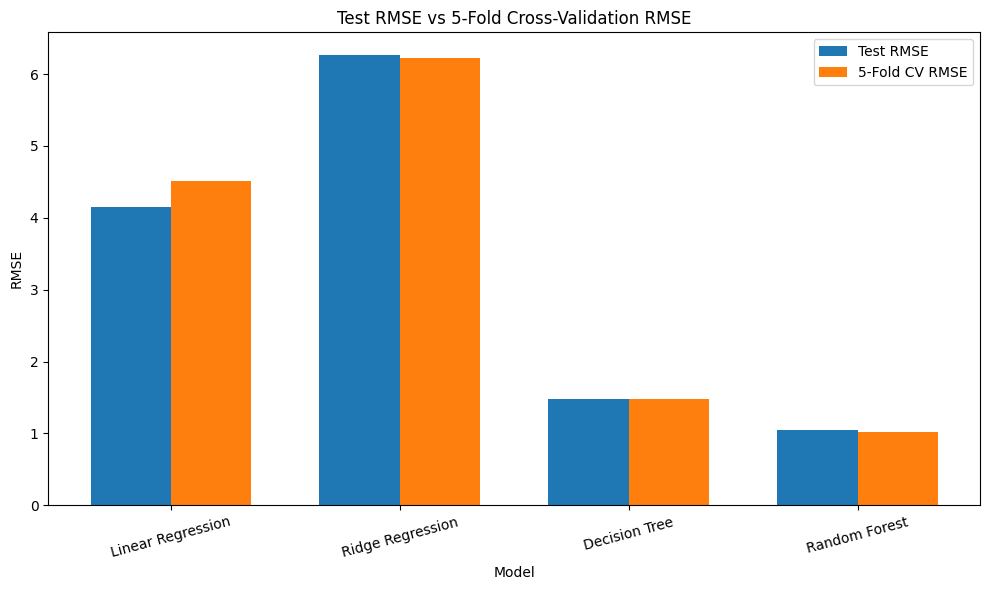

In [24]:
# C18 - Test RMSE vs Cross-Validation RMSE

plt.figure(figsize=(10, 6))

x = np.arange(len(comparison_df['Model']))
width = 0.35

plt.bar(
    x - width/2,
    comparison_df['RMSE'],
    width,
    label='Test RMSE'
)

plt.bar(
    x + width/2,
    comparison_df['Mean CV RMSE'],
    width,
    label='5-Fold CV RMSE'
)

plt.xticks(x, comparison_df['Model'], rotation=15)
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.title('Test RMSE vs 5-Fold Cross-Validation RMSE')
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
# C19 - Identify the best model based on CV RMSE

best_model_row = comparison_df.loc[
    comparison_df['Mean CV RMSE'].idxmin()
]

print("Best Model Based on 5-Fold Cross-Validation:")
print("Model:", best_model_row['Model'])
print("Mean CV RMSE:", round(best_model_row['Mean CV RMSE'], 4))
print("Test RMSE:", round(best_model_row['RMSE'], 4))
print("Test MAE:", round(best_model_row['MAE'], 4))
print("Test R²:", round(best_model_row['R2'], 4))

Best Model Based on 5-Fold Cross-Validation:
Model: Random Forest
Mean CV RMSE: 1.0252
Test RMSE: 1.0439
Test MAE: 0.3541
Test R²: 0.999


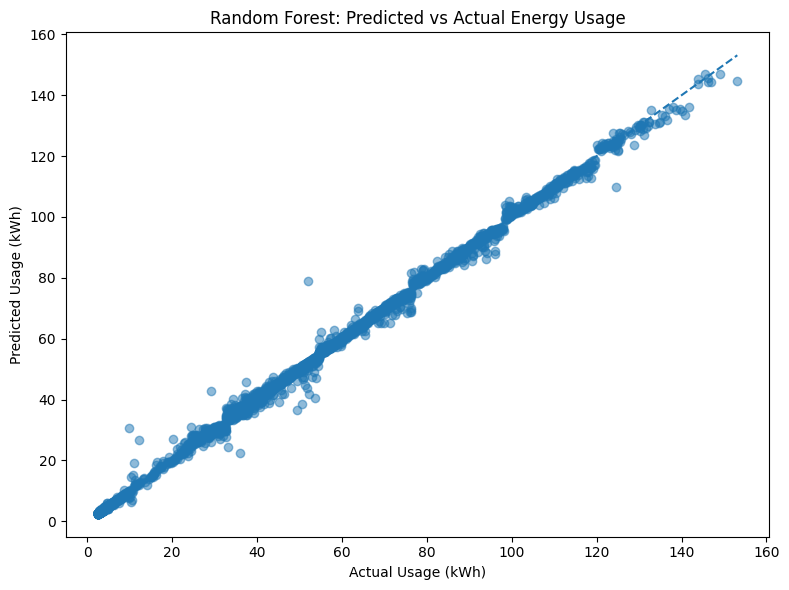

In [26]:
# C20 - Predicted vs Actual values for the best model

best_model = pipelines['Random Forest']

# Generate predictions using the test set
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Usage (kWh)')
plt.ylabel('Predicted Usage (kWh)')
plt.title('Random Forest: Predicted vs Actual Energy Usage')

plt.tight_layout()
plt.show()

In [27]:
# Final evaluation of the selected Random Forest model

final_mae = mean_absolute_error(y_test, y_pred_best)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
final_r2 = r2_score(y_test, y_pred_best)

print("Final Selected Model: Random Forest")
print("-----------------------------------")
print(f"MAE:  {final_mae:.4f}")
print(f"RMSE: {final_rmse:.4f}")
print(f"R²:   {final_r2:.4f}")

Final Selected Model: Random Forest
-----------------------------------
MAE:  0.3541
RMSE: 1.0439
R²:   0.9990


## Model Selection

Based on the test-set evaluation and 5-fold cross-validation results, the Random Forest Regressor was selected as the best-performing baseline model.

The Random Forest achieved a test RMSE of 1.0439, a test MAE of 0.3541, and an R² score of 0.9990. Its mean 5-fold cross-validation RMSE was 1.0252, which was the lowest among all four models tested.

The other models produced higher errors. Linear Regression achieved a test RMSE of 4.1460 and a mean cross-validation RMSE of 4.5125. Ridge Regression produced a test RMSE of 6.2666 and a mean cross-validation RMSE of 6.2285. The Decision Tree performed considerably better, with a test RMSE of 1.4737 and a mean cross-validation RMSE of 1.4785, but it was still less accurate than Random Forest.

The Random Forest showed no major sign of overfitting based on the comparison between its test RMSE (1.0439) and cross-validation RMSE (1.0252). The difference is small, indicating that the model performs consistently across different validation folds and the held-out test set.

Therefore, the Random Forest Regressor will be carried forward as the baseline model for further development and improvement.